# EDP — Equal Differential Planes (equal areas)

Manual scratchpad for the numeric equal-areas method (`dt.fit_edp`,
`method="edp"`). Integration-based, so it is noise-robust and works on raw
data without any polynomial pre-fit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dtfit as dt
from dtfit.simulation import apply_normal_noise

dt.enable_logging()

<Logger dtfit (INFO)>

## Data — saturating  y = 5·arctan(1.5 x)

In [2]:
x = np.linspace(0, 10, 400)
y_true = 5.0 * np.arctan(1.5 * x)
y = apply_normal_noise(y_true, 0.0, 0.3, seed=0)

## Fit (function form)

In [3]:
res = dt.fit_edp(x, y, "a*atan(w*x)", "x", p0=[1.0, 1.0])
print("coeffs (a, w):", res.coeffs)  # true: 5.0, 1.5

coeffs (a, w): [4.96736819 1.57845906]


## Fit (pipeline form) — no FindPolyDegree / FittingPoly needed

In [4]:
model = dt.Model()
model.use(dt.FittingNonlineMw("a*atan(w*x)", "x", method="edp"))
data = model.fit(x, y)
print("pipeline coeffs:", data.coeffs)

pipeline coeffs: [4.96736819 1.57845906]


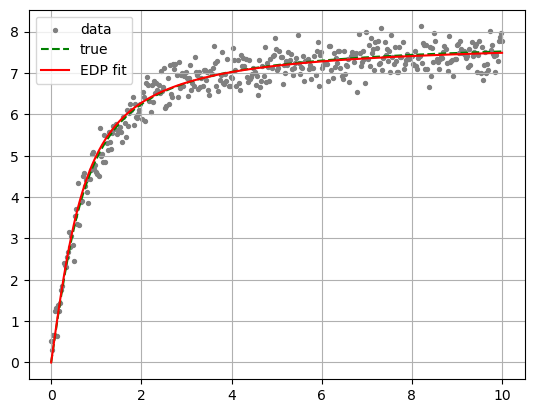

In [5]:
plt.scatter(x, y, s=8, color="gray", label="data")
plt.plot(x, y_true, "g--", label="true")
plt.plot(x, res.model(x), "r-", label="EDP fit")
plt.legend(); plt.grid(True); plt.show()